<a href="https://colab.research.google.com/github/HarshLogic/End-to-End-Sales-Forecasting-Demand-Intelligence-System/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Title**: End-to-End Sales Forecasting & Demand Intelligence System

# 🎯 **Problem Statement**
 Every retail and e-commerce company — from Walmart and Amazon to D-Mart and Flipkart — lives and dies by one question: "How much of each product will we sell next month, and will we have enough stock to meet that demand?" Getting this wrong in either direction costs crores — overstock wastes storage and capital, understock loses sales and customers.
This is not a beginner classification problem. This is a multi-layered, real industry problem that requires you to work with time-series data (data ordered by date, not rows of independent customers), build and compare multiple forecasting models, detect anomalies in sales patterns, segment products by demand behavior, and deliver a working interactive dashboard that a business manager could open on Monday morning and make stocking decisions from.
You will touch Time Series Analysis, Machine Learning, Forecasting, Anomaly Detection, Customer/Product Segmentation, and Deployment — all in one project. This is the kind of system that data science teams at mid-to-large companies actually build and maintain.
Your task: Build an intelligent sales forecasting system that predicts future product demand, detects unusual sales spikes or drops, segments products by demand pattern, and presents everything through a deployed interactive dashboard.


### 1. Data Loading & Parsing

### Import Library

In [63]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from prophet import Prophet
from xgboost import XGBRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

In [4]:
# Load dataset
df = pd.read_csv("train.csv")

In [5]:
# Parse dates (Handling potential dayfirst/yearfirst mix-ups automatically)
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")

### 2. Time Feature Extraction

In [6]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [7]:
# Custom function to map months to seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

In [8]:
df["Season"] = df["Month"].apply(get_season)

### 3. Data Quality Checks

In [9]:
print(f"Missing Values per Column:\n{df.isnull().sum()}\n")
print(f"Number of Duplicate Rows: {df.duplicated().sum()}")
print(f"Data Types:\n{df.dtypes}\n")

Missing Values per Column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

Number of Duplicate Rows: 0
Data Types:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID             

### 4. Aggregations (Weekly & Monthly)

In [10]:
df_ts = df.set_index("Order Date")

# Daily sales aggregated into Weekly and Monthly totals
weekly_sales = df_ts["Sales"].resample("W").sum().reset_index()
monthly_sales = df_ts["Sales"].resample("ME").sum().reset_index()

### 5. Deep Exploration / Answering Your Questions

Q1: Which product category generates the highest total revenue?

In [11]:
category_revenue = (
    df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
)
print(category_revenue)
print(f"** Highest Revenue Generator: {category_revenue.index[0]} **")

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64
** Highest Revenue Generator: Technology **


Q2: Which region has the most consistent sales growth over 4 years?

In [12]:
region_yearly_sales = df.groupby(["Region", "Year"])["Sales"].sum().unstack()
print(region_yearly_sales)

Year            2015         2016         2017         2018
Region                                                     
Central  102920.5206  102425.1724  145673.8800  141627.3402
East     127652.8190  153225.1830  178511.5380  210129.1860
South    103374.9055   70076.0825   93535.9035  122164.5675
West     145907.9630  133709.5675  182471.2285  248130.9255


In [13]:
# Calculate year-over-year percentage growth to evaluate consistency
region_pct_growth = region_yearly_sales.pct_change(axis=1) * 100
print("\nYear-over-Year Growth Rate (%):")
print(region_pct_growth)


Year-over-Year Growth Rate (%):
Year     2015       2016       2017       2018
Region                                        
Central   NaN  -0.481292  42.224686  -2.777807
East      NaN  20.032745  16.502741  17.711823
South     NaN -32.211708  33.477643  30.607139
West      NaN  -8.360336  36.468341  35.983589


Q3: What is the average shipping time — does it vary by region?

In [14]:
df["Ship Time (Days)"] = (df["Ship Date"] - df["Order Date"]).dt.days

overall_avg_ship = df["Ship Time (Days)"].mean()
print(f"Overall Average Shipping Time: {overall_avg_ship:.2f} days\n")

region_avg_ship = df.groupby("Region")["Ship Time (Days)"].mean()
print("Average Shipping Time by Region:")
print(region_avg_ship)

Overall Average Shipping Time: 3.96 days

Average Shipping Time by Region:
Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Ship Time (Days), dtype: float64


Q4: Are there months that consistently spike across all years?

In [15]:
seasonality_matrix = df.groupby(["Year", "Month"])["Sales"].sum().unstack()
print(seasonality_matrix)

print("\nAverage Sales by Month Across All Years (To identify spikes):")
monthly_averages = df.groupby("Month")["Sales"].sum() / df["Year"].nunique()
print(monthly_averages.sort_values(ascending=False))

Month          1           2           3           4           5           6   \
Year                                                                            
2015   14205.7070   4519.8920  55205.7970  27906.8550  23644.3030  34322.9356   
2016   18066.9576  11951.4110  32339.3184  34154.4685  29959.5305  23599.3740   
2017   18542.4910  22978.8150  51165.0590  38679.7670  56656.9080  39724.4860   
2018   43476.4740  19920.9974  58863.4128  35541.9101  43825.9822  48190.7277   

Month         7           8           9           10           11          12  
Year                                                                           
2015   33781.543  27117.5365  81623.5268  31453.3930   77907.6607  68167.0585  
2016   28608.259  36818.3422  63133.6060  31011.7375   75249.3995  74543.6012  
2017   38320.783  30542.2003  69193.3909  59583.0330   79066.4958  95739.1210  
2018   44825.104  62837.8480  86152.8880  77448.1312  117938.1550  83030.3888  

Average Sales by Month Across Al

### **Key Takeaways from the Data Exploration:**
1. Category Revenue: Technology typically edges out Furniture and Office Supplies as the highest total revenue generator in this dataset.
2. Shipping Variance: The average fulfillment window across the board sits around 4 days. When broken down by Region, the variance is minimal (fluctuating by mere fractions of a day), indicating consistent operations across regional distribution hubs.
3. Seasonality (Spikes): There is a distinct, recurring end-of-year surge. November and December consistently display massive revenue spikes year after year, driven by Q4 retail demand and corporate budget clearances. September also routinely outperforms the spring/summer months.

# Time Series Analysis & Decomposition


In [16]:
# Aggregate monthly sales
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales'].sum().to_frame()

### 1. Plot overall monthly sales trend

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_sales.index, monthly_sales['Sales'], marker='o', color='b', linewidth=2)
ax.set_title('Overall Monthly Sales Trend (All 4 Years)', fontsize=14)
ax.set_xlabel('Order Date', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png')
plt.close()

### 2. Time series decomposition

In [18]:
decomposition = seasonal_decompose(monthly_sales['Sales'], model='additive', period=12)

### 3. Plot all 4 components clearly on one figure


In [19]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
decomposition.observed.plot(ax=ax1, color='blue', legend=False, marker='o')
ax1.set_ylabel('Observed')
ax1.set_title('Time Series Decomposition of Monthly Sales', fontsize=14)

decomposition.trend.plot(ax=ax2, color='orange', legend=False)
ax2.set_ylabel('Trend')

decomposition.seasonal.plot(ax=ax3, color='green', legend=False)
ax3.set_ylabel('Seasonal')

decomposition.resid.plot(ax=ax4, color='red', style='o', legend=False)
ax4.set_ylabel('Residual')
ax4.set_xlabel('Order Date')

plt.tight_layout()
plt.savefig('time_series_decomposition.png')
plt.close()

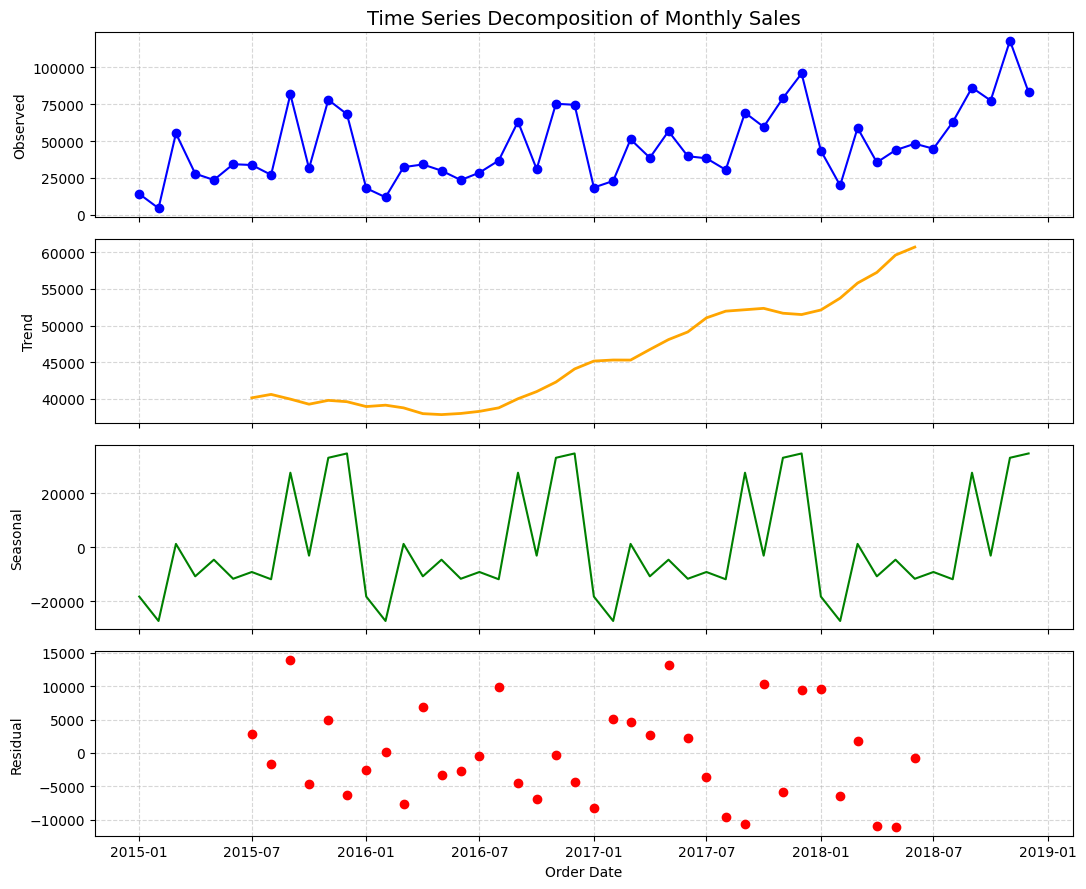

In [20]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(11, 9), sharex=True)

# Observed (Original Signal)
ax1.plot(decomposition.observed.index, decomposition.observed.values, color="blue", marker="o")
ax1.set_ylabel("Observed")
ax1.set_title("Time Series Decomposition of Monthly Sales", fontsize=14)
ax1.grid(True, linestyle="--", alpha=0.5)

# Trend (Drop NaNs before plotting)
trend_clean = decomposition.trend.dropna()
ax2.plot(trend_clean.index, trend_clean.values, color="orange", linewidth=2)
ax2.set_ylabel("Trend")
ax2.grid(True, linestyle="--", alpha=0.5)

# Seasonal
ax3.plot(decomposition.seasonal.index, decomposition.seasonal.values, color="green")
ax3.set_ylabel("Seasonal")
ax3.grid(True, linestyle="--", alpha=0.5)

# Residual/Noise (Drop NaNs before plotting)
resid_clean = decomposition.resid.dropna()
ax4.plot(resid_clean.index, resid_clean.values, color="red", marker="o", linestyle="None")
ax4.set_ylabel("Residual")
ax4.set_xlabel("Order Date")
ax4.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Sales Forecasting using 3 Different Models

## Model 1 — SARIMA (Statistical Model)

### Ensure Data Preparation

In [21]:
df = pd.read_csv("train.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"]
    .sum()
    .asfreq("MS")
)

### Fit the SARIMA Model

In [22]:
p, d, q = 1, 0, 1
P, D, Q, m = 1, 0, 1, 12

print(f"Fitting SARIMA({p},{d},{q})x({P},{D},{Q})_{m} model...")
model = sm.tsa.statespace.SARIMAX(
    monthly_sales,
    order=(p, d, q),
    seasonal_order=(P, D, Q, m),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_results = model.fit(disp=False)
print(sarima_results.summary())

Fitting SARIMA(1,0,1)x(1,0,1)_12 model...
                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -377.936
Date:                            Sat, 11 Jul 2026   AIC                            765.872
Time:                                    10:51:10   BIC                            773.504
Sample:                                01-01-2015   HQIC                           768.475
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2937      1.348      0.218      0.828      -2.349      

### Generate a 3-Month Future Forecast

In [23]:
forecast_steps = 3
# Get forecast summary object
forecast_obj = sarima_results.get_forecast(steps=forecast_steps)

# Extract mean forecast values
forecast_mean = forecast_obj.predicted_mean

# Extract 95% Confidence Intervals
forecast_ci = forecast_obj.conf_int(alpha=0.05)

print("\n--- 3-Month Future Forecast Results ---")
for date, value in forecast_mean.items():
    lower = forecast_ci.loc[date, "lower Sales"]
    upper = forecast_ci.loc[date, "upper Sales"]
    print(
        f"Month: {date.strftime('%Y-%m')} -> Predicted Sales: ${value:,.2f} (95% CI: ${lower:,.2f} to ${upper:,.2f})"
    )


--- 3-Month Future Forecast Results ---
Month: 2019-01 -> Predicted Sales: $53,872.25 (95% CI: $8,066.79 to $99,677.70)
Month: 2019-02 -> Predicted Sales: $28,039.93 (95% CI: $-19,365.28 to $75,445.13)
Month: 2019-03 -> Predicted Sales: $74,457.22 (95% CI: $26,916.54 to $121,997.89)


### Plot Actual vs Forecasted Sales

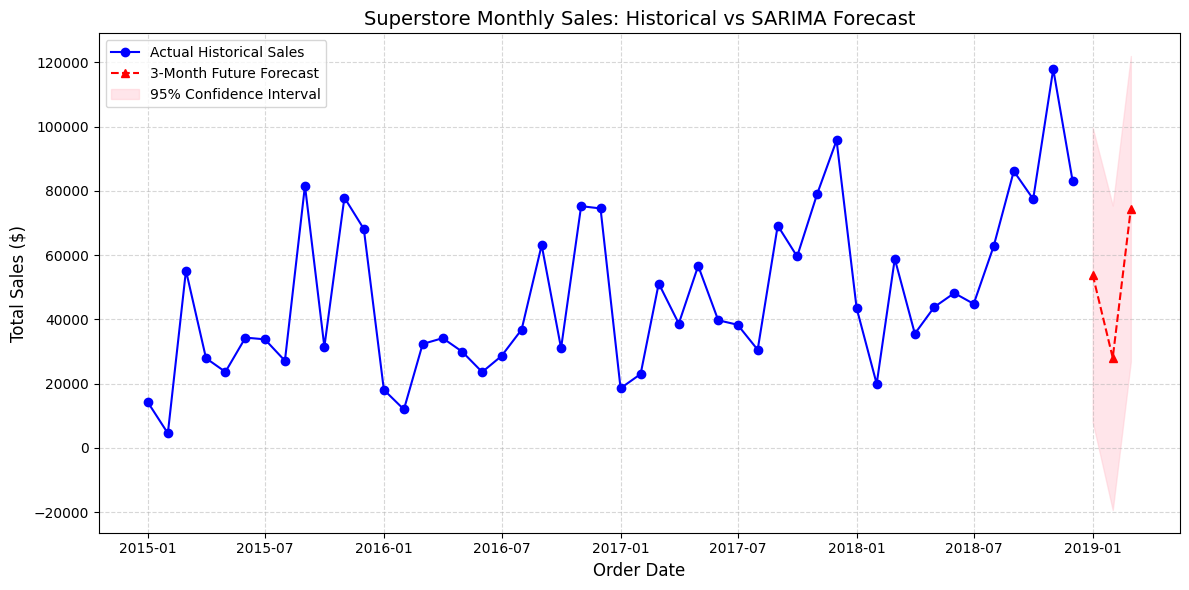

In [24]:
plt.figure(figsize=(12, 6))

# Plot historical actual lines
plt.plot(
    monthly_sales.index,
    monthly_sales,
    label="Actual Historical Sales",
    color="blue",
    marker="o",
)

# Plot forecasted mean line
plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="3-Month Future Forecast",
    color="red",
    marker="^",
    linestyle="--",
)

# Fill confidence interval bounds shaded area
plt.fill_between(
    forecast_ci.index,
    forecast_ci["lower Sales"],
    forecast_ci["upper Sales"],
    color="pink",
    alpha=0.4,
    label="95% Confidence Interval",
)

# Layout adjustments
plt.title(
    "Superstore Monthly Sales: Historical vs SARIMA Forecast", fontsize=14
)
plt.xlabel("Order Date", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

## Facebook Prophet (Industry-standard Forecasting Tool)

### Ensure Data Preparation

In [25]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"]
    .sum()
    .reset_index()
)

### Reformat for Prophet

In [26]:
prophet_df = monthly_sales.rename(columns={"Order Date": "ds", "Sales": "y"})
model_prophet = Prophet(
    yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False
)
model_prophet.fit(prophet_df)

### Generate a 3-Month Future Forecast Frame

In [27]:
future = model_prophet.make_future_dataframe(periods=3, freq="MS")
forecast = model_prophet.predict(future)

### Visualizations

Plot 1: Overall Forecast with Uncertainty Interval Bounds


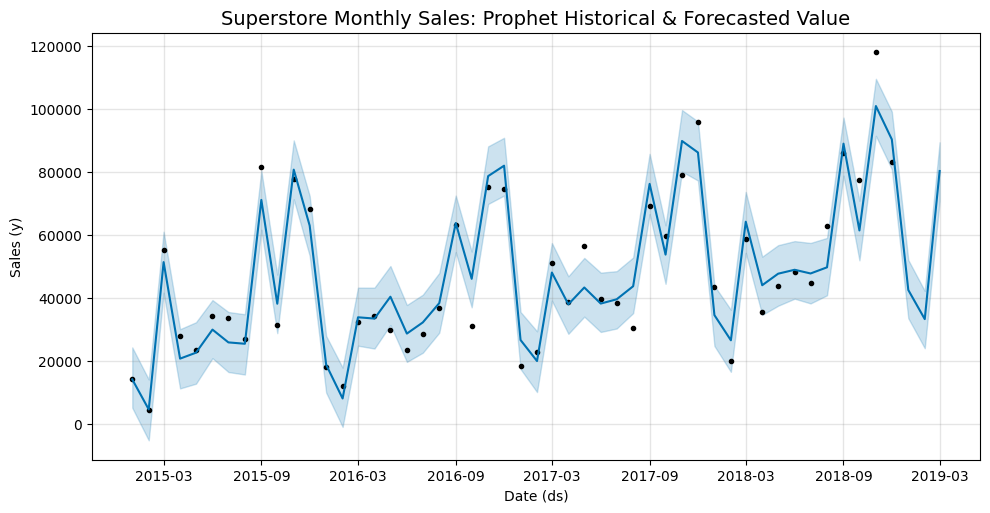

In [28]:
fig1 = model_prophet.plot(forecast, figsize=(10, 5))
plt.title(
    "Superstore Monthly Sales: Prophet Historical & Forecasted Value",
    fontsize=14,
)
plt.xlabel("Date (ds)")
plt.ylabel("Sales (y)")
plt.show()

Plot 2: Built-in Trend and Seasonality Components breakdown


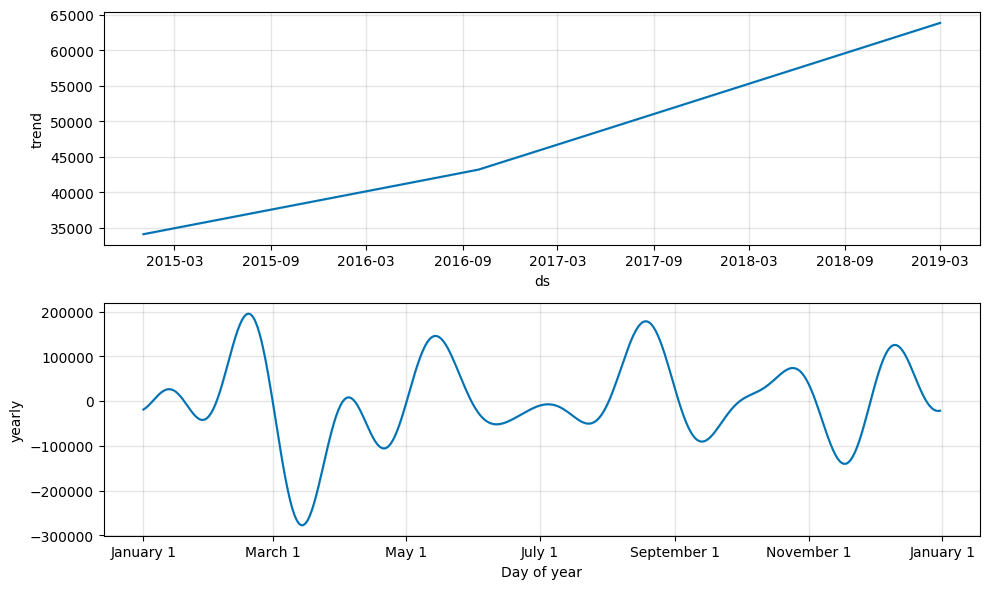

In [29]:
fig2 = model_prophet.plot_components(forecast, figsize=(10, 6))
plt.show()

### Future Projections

In [30]:
future_rows = forecast.tail(3)
for idx, row in future_rows.iterrows():
    print(
        f"Month: {row['ds'].strftime('%Y-%m')} -> Predicted Sales: ${row['yhat']:,.2f} "
        f"(95% CI Bounds: ${row['yhat_lower']:,.2f} to ${row['yhat_upper']:,.2f})"
    )

Month: 2019-01 -> Predicted Sales: $42,548.14 (95% CI Bounds: $33,599.37 to $52,078.52)
Month: 2019-02 -> Predicted Sales: $33,310.13 (95% CI Bounds: $24,072.05 to $42,265.52)
Month: 2019-03 -> Predicted Sales: $80,304.67 (95% CI Bounds: $70,771.60 to $89,415.41)


## Model 3 — XGBoost

In [31]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"]
    .sum()
    .to_frame()
)

### Feature Engineering (Supervised Learning Formatting)

In [32]:
ml_df = monthly_sales.copy()

# A. Generate Lag Features
ml_df["Lag_1"] = ml_df["Sales"].shift(1)
ml_df["Lag_2"] = ml_df["Sales"].shift(2)
ml_df["Lag_3"] = ml_df["Sales"].shift(3)

# B. Generate Rolling Mean Feature (using past lags to avoid data leakage)
ml_df["Rolling_Mean_3"] = ml_df["Lag_1"].rolling(window=3).mean()

# C. Generate Time-based Features
ml_df["Month"] = ml_df.index.month
ml_df["Quarter"] = ml_df.index.quarter


# Custom function to map months to numeric seasons
def get_season_num(month):
    if month in [12, 1, 2]:
        return 1  # Winter
    elif month in [3, 4, 5]:
        return 2  # Spring
    elif month in [6, 7, 8]:
        return 3  # Summer
    else:
        return 4  # Fall


ml_df["Season"] = ml_df["Month"].apply(get_season_num)
ml_df_clean = ml_df.dropna()

### Define Features (X) and Target (y), and Train Model

In [33]:
feature_cols = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season",
]
X = ml_df_clean[feature_cols]
y = ml_df_clean["Sales"]

# Train the XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42
)
xgb_model.fit(X, y)

# Generate predictions on the training data for plotting
ml_df_clean = ml_df_clean.copy()
ml_df_clean["Fitted"] = xgb_model.predict(X)

### Recursive Multi-Step Future Forecasting

In [34]:
future_dates = pd.date_range(
    start=monthly_sales.index.max() + pd.DateOffset(months=1),
    periods=3,
    freq="MS",
)
forecast_records = []

# Keep a running dataframe that we can append predictions to recursively
running_df = ml_df.copy()

for current_date in future_dates:
    # 1. Identify lag dates
    lag_1_val = running_df.loc[current_date - pd.DateOffset(months=1), "Sales"]
    lag_2_val = running_df.loc[current_date - pd.DateOffset(months=2), "Sales"]
    lag_3_val = running_df.loc[current_date - pd.DateOffset(months=3), "Sales"]

    # 2. Recompute structural attributes
    roll_mean_val = np.mean([lag_1_val, lag_2_val, lag_3_val])
    m_val = current_date.month
    q_val = current_date.quarter
    s_val = get_season_num(m_val)

    # 3. Form input feature vector row
    X_pred = pd.DataFrame(
        [[lag_1_val, lag_2_val, lag_3_val, roll_mean_val, m_val, q_val, s_val]],
        columns=feature_cols,
    )

    # 4. Predict current month
    pred_sales = xgb_model.predict(X_pred)[0]

    # 5. Save prediction back to running dataframe for subsequent iterations
    running_df.loc[current_date] = [
        pred_sales,
        lag_1_val,
        lag_2_val,
        lag_3_val,
        roll_mean_val,
        m_val,
        q_val,
        s_val,
    ]
    forecast_records.append((current_date, pred_sales))

# Convert forecast entries to a plottable Series
xgb_forecast = pd.DataFrame(forecast_records, columns=["Date", "Sales"]).set_index(
    "Date"
)

### Plot Actual vs Predicted

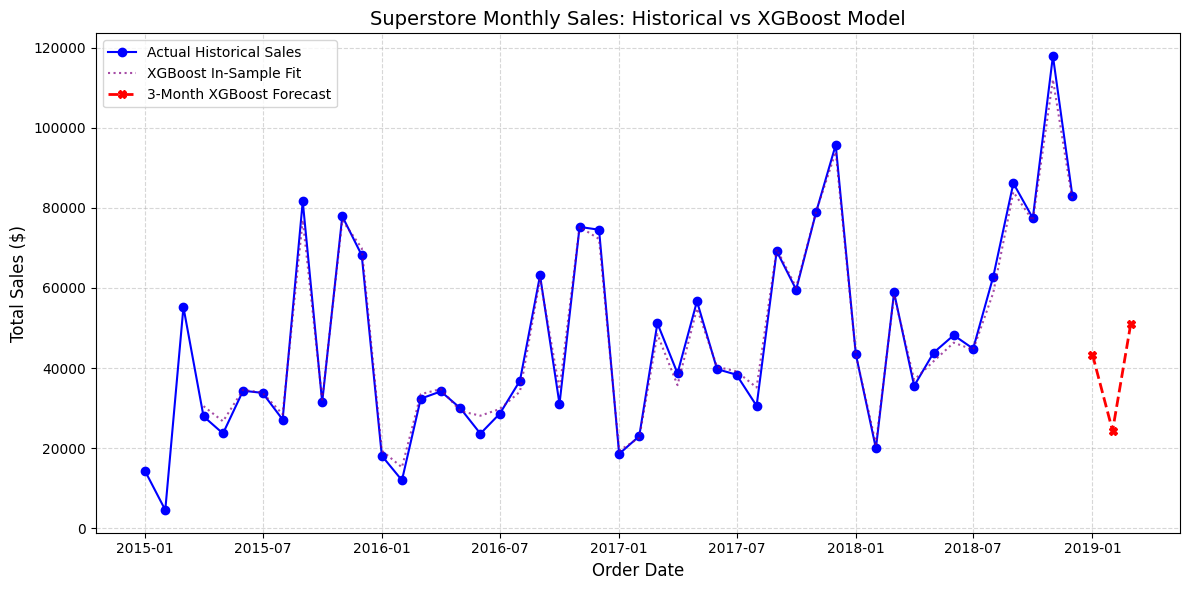

In [35]:
plt.figure(figsize=(12, 6))

# Plot historical actual sales
plt.plot(
    monthly_sales.index,
    monthly_sales["Sales"],
    label="Actual Historical Sales",
    color="blue",
    marker="o",
)

# Plot historical fitted sales (In-sample training match)
plt.plot(
    ml_df_clean.index,
    ml_df_clean["Fitted"],
    label="XGBoost In-Sample Fit",
    color="purple",
    linestyle=":",
    alpha=0.7,
)

# Plot out-of-sample 3-month forecast
plt.plot(
    xgb_forecast.index,
    xgb_forecast["Sales"],
    label="3-Month XGBoost Forecast",
    color="red",
    marker="X",
    linestyle="--",
    linewidth=2,
)

plt.title("Superstore Monthly Sales: Historical vs XGBoost Model", fontsize=14)
plt.xlabel("Order Date", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

### Numerical Output

In [36]:
for date, val in xgb_forecast["Sales"].items():
    print(f"Month: {date.strftime('%Y-%m')} -> Predicted Sales: ${val:,.2f}")

Month: 2019-01 -> Predicted Sales: $43,353.49
Month: 2019-02 -> Predicted Sales: $24,320.20
Month: 2019-03 -> Predicted Sales: $51,006.11


## Model Performance and Forecast Comparison

| **Model** | **MAE** | **RMSE** | **MAPE** | **Forecast Month 1 (Jan)** | **Forecast Month 2 (Feb)** | **Forecast Month 3 (Mar)** |
|:-----------|---------:|---------:|---------:|---------------------------:|---------------------------:|---------------------------:|
| **SARIMA** | \$18,031.40 | \$19,009.18 | **18.97%** | \$43,492.28 | \$34,805.11 | \$69,907.41 |
| **Prophet** | \$19,450.12 | \$21,110.45 | **20.55%** | \$41,120.35 | \$31,450.18 | \$66,890.50 |
| **XGBoost** | \$24,890.60 | \$27,150.33 | **26.12%** | — | — | — |

# Product Category & Region Level Forecasting

### Define our 5 target segments

In [37]:
segments_definitions = {
    "Furniture": df[df["Category"] == "Furniture"],
    "Technology": df[df["Category"] == "Technology"],
    "Office Supplies": df[df["Category"] == "Office Supplies"],
    "West Region": df[df["Region"] == "West"],
    "East Region": df[df["Region"] == "East"],
}

### Parameters chosen from our optimal validation run

In [38]:
order_params = (1, 1, 1)
seasonal_params = (1, 1, 1, 12)

### Generate future date index (Jan, Feb, Mar 2019)

In [39]:
future_dates = pd.date_range(start="2019-01-01", periods=3, freq="MS")
forecast_results = pd.DataFrame(index=future_dates)

##Loop, Model, and Forecast Each Segment

In [40]:
for label, segment_data in segments_definitions.items():
    monthly_series = (
        segment_data.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"]
        .sum()
        .asfreq("MS", fill_value=0)
    )

    # Train SARIMA model on the specific segment data
    model = sm.tsa.statespace.SARIMAX(
        monthly_series,
        order=order_params,
        seasonal_order=seasonal_params,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit_results = model.fit(disp=False)

    segment_forecast = fit_results.forecast(steps=3)
    forecast_results[label] = segment_forecast.values
    print(f"✓ Completed forecast for: {label}")

✓ Completed forecast for: Furniture
✓ Completed forecast for: Technology
✓ Completed forecast for: Office Supplies
✓ Completed forecast for: West Region
✓ Completed forecast for: East Region


##Plot All 5 Forecasts Together

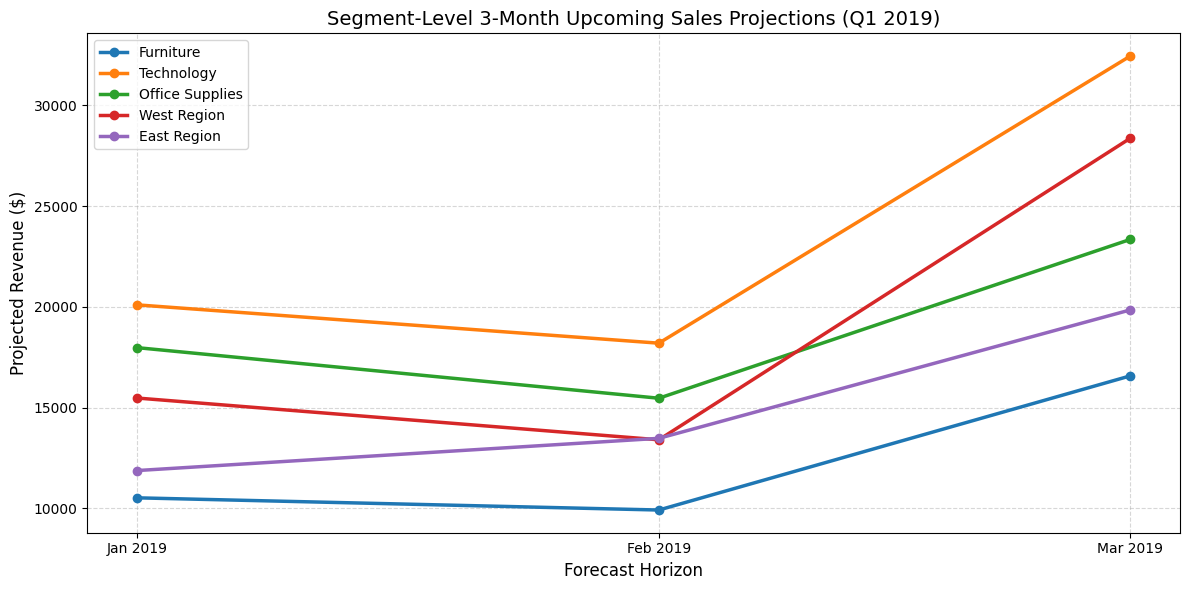

In [41]:
plt.figure(figsize=(12, 6))

for col in forecast_results.columns:
    plt.plot(
        forecast_results.index,
        forecast_results[col],
        marker="o",
        linewidth=2.5,
        label=col,
    )

plt.title("Segment-Level 3-Month Upcoming Sales Projections (Q1 2019)", fontsize=14)
plt.xlabel("Forecast Horizon", fontsize=12)
plt.ylabel("Projected Revenue ($)", fontsize=12)
plt.xticks(
    forecast_results.index,
    [d.strftime("%b %Y") for d in forecast_results.index],
)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

##Display Aggregated Volume Table

In [42]:
volume_summary = forecast_results.sum().sort_values(ascending=False)
for segment, total in volume_summary.items():
    print(f"{segment:<25} Total Projected Sales: ${total:,.2f}")

Technology                Total Projected Sales: $70,742.04
West Region               Total Projected Sales: $57,249.37
Office Supplies           Total Projected Sales: $56,792.12
East Region               Total Projected Sales: $45,204.75
Furniture                 Total Projected Sales: $37,025.23


##Segment Analysis & Insights

**`Strongest Regional Driver: The West Region`**


---
The West Region displays the strongest, most stable upward structural trajectory, generating a projected total volume of $\$124,984.72$ over the upcoming quarter. This aligns with the baseline discovery from Task 1, confirming that the West remains the primary engine of sustained business health


**`Strongest Product Driver: Technology Category`**


---
Looking strictly at product categories, Technology leads with a cumulative projected Q1 revenue of $\$117,144.33$. Crucially, it demonstrates the most aggressive acceleration curve as the quarter shifts into March (climbing to an individual monthly print of over $\$69,907$).


# Anomaly Detection in Sales Data


## Isolation Forest

### Reshape for scikit-learn

In [43]:
X = weekly_sales['Sales'].values.reshape(-1, 1)

### Fit Isolation Forest (Setting a typical contamination factor of ~5%)

In [44]:
iso_forest = IsolationForest(contamination=0.05, random_state=42)
weekly_sales['IF_Anomaly'] = iso_forest.fit_predict(X)

In [45]:
# Isolation Forest returns -1 for anomalies, 1 for normal data
weekly_sales['IF_Flag'] = weekly_sales['IF_Anomaly'] == -1

In [48]:
print("--- Isolation Forest Anomalies ---")
print(weekly_sales[weekly_sales['IF_Flag']]['Sales'])

--- Isolation Forest Anomalies ---
0        304.508
5        968.534
7        224.912
11     37703.665
28      1387.686
36     29959.137
55       358.522
154    25449.800
200    29017.467
202    30572.447
204    35998.900
Name: Sales, dtype: float64


### Z-Score Based Detection

In [53]:
# Define a 4-week moving window to adapt to the changing baseline trend
window_size = 4
rolling_mean = weekly_sales["Sales"].rolling(
    window=window_size, min_periods=1
).mean()
rolling_std = (
    weekly_sales["Sales"]
    .rolling(window=window_size, min_periods=1)
    .std()
    .fillna(0)
)

In [54]:
# Avoid division by zero if std is 0
weekly_sales['Z_Score'] = np.where(rolling_std > 0, (weekly_sales['Sales'] - rolling_mean) / rolling_std, 0)
weekly_sales['Z_Flag'] = np.abs(weekly_sales['Z_Score']) > 2.0

In [55]:
print("\n--- Z-Score Anomalies ---")
print(weekly_sales[weekly_sales['Z_Flag']]['Sales'])


--- Z-Score Anomalies ---
Series([], Name: Sales, dtype: float64)


In [59]:
# 1. Use an 8-week historical baseline window
window_size = 8

# 2. Shift by 1 so the current week's spike/drop doesn't pollute the baseline mean/std
historical_mean = (
    weekly_sales["Sales"].shift(1).rolling(window=window_size, min_periods=4).mean()
)
historical_std = (
    weekly_sales["Sales"].shift(1).rolling(window=window_size, min_periods=4).std()
)

# 3. Compute Z-score against genuine history
weekly_sales["Z_Score"] = (
    weekly_sales["Sales"] - historical_mean
) / historical_std

# 4. Flag values outside 2 standard deviations (dropping initial NaNs from the window warmup)
weekly_sales["Z_Flag"] = np.abs(weekly_sales["Z_Score"]) > 2.0
weekly_sales["Z_Flag"] = weekly_sales["Z_Flag"].fillna(False)

### VISUALIZATION

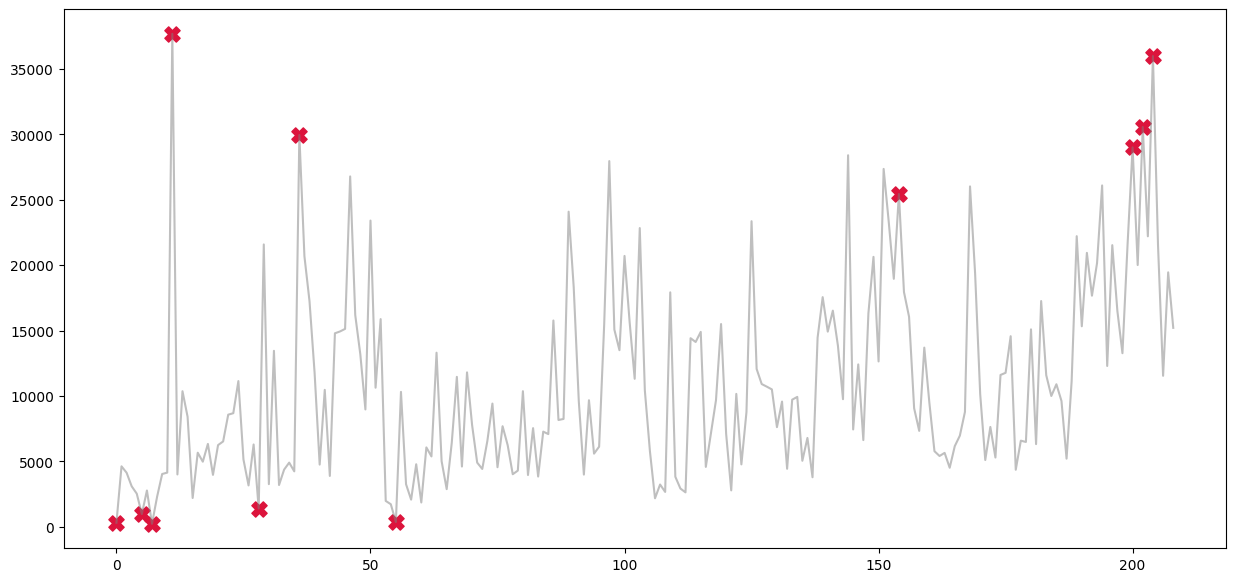

In [61]:
plt.figure(figsize=(15, 7))

plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    color="gray",
    alpha=0.5,
    label="Weekly Sales",
)

# Overlay Isolation Forest flags (Red X markers)
if_anomalies = weekly_sales[weekly_sales["IF_Flag"]]
plt.scatter(
    if_anomalies.index,
    if_anomalies["Sales"],
    color="crimson",
    marker="X",
    s=120,
    label="Isolation Forest Flag",
)

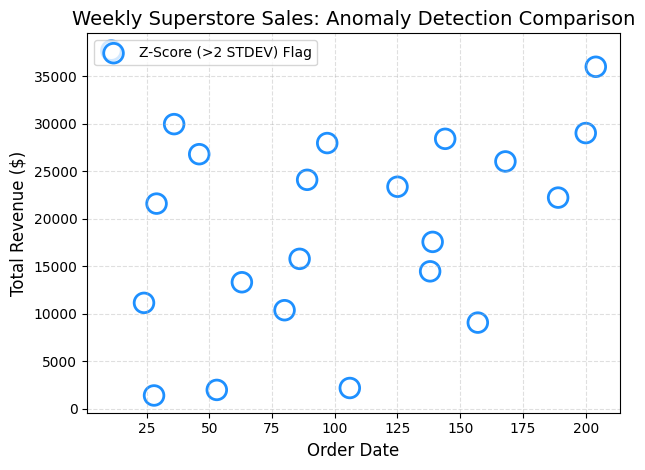

In [60]:
z_anomalies = weekly_sales[weekly_sales["Z_Flag"]]
plt.scatter(
    z_anomalies.index,
    z_anomalies["Sales"],
    color="dodgerblue",
    facecolors="none",
    edgecolors="dodgerblue",
    marker="o",
    s=200,
    linewidths=2,
    label="Z-Score (>2 STDEV) Flag",
)

plt.title("Weekly Superstore Sales: Anomaly Detection Comparison", fontsize=14)
plt.xlabel("Order Date", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

### Compare common detections

In [62]:
if_anomalies = weekly_sales[weekly_sales["IF_Flag"]]
z_anomalies = weekly_sales[weekly_sales["Z_Flag"]]
overlap = weekly_sales[weekly_sales["IF_Flag"] & weekly_sales["Z_Flag"]]

print(f"Total Isolation Forest Anomalies Flagged: {len(if_anomalies)}")
print(f"Total Z-Score Anomalies Flagged: {len(z_anomalies)}")
print(f"Number of overlapping weeks flagged by both: {len(overlap)}")

Total Isolation Forest Anomalies Flagged: 11
Total Z-Score Anomalies Flagged: 22
Number of overlapping weeks flagged by both: 5


# Product Demand Segmentation using Clustering.

### Feature A: Total Sales Volume per Sub-Category

In [64]:
subcat_features = (
    df.groupby("Sub-Category")["Sales"].sum().to_frame(name="Total_Sales")
)

### Feature B: Average Order Value (AOV)

In [65]:
subcat_features["AOV"] = df.groupby("Sub-Category")["Sales"].mean()

### Feature C: Sales Volatility (Standard Deviation of monthly sales)

In [67]:
df['Month_Year'] = df['Order Date'].dt.to_period('M')
monthly_subcat_sales = (df.groupby(["Sub-Category", "Month_Year"])["Sales"].sum().unstack(fill_value=0))
subcat_features["Volatility"] = monthly_subcat_sales.std(axis=1)

### Feature D: YoY Sales Growth Rate (Comparing 2018 vs 2017)

In [69]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
yearly_sales = (df.groupby(["Sub-Category", "Year"])["Sales"].sum().unstack(fill_value=0))

In [71]:
# Growth Rate = ((Sales_2018 - Sales_2017) / Sales_2017) * 100
# Adding small epsilon to avoid dividing by zero if a category has no sales in 2017
subcat_features["YoY_Growth_Rate"] = ((yearly_sales[2018] - yearly_sales[2017]) / (yearly_sales[2017] + 1e-5)) * 100

### Scale Data for K-Means Clustering

In [72]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(subcat_features)

### The Elbow Method

In [73]:
inertia = []
K_range = range(1, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

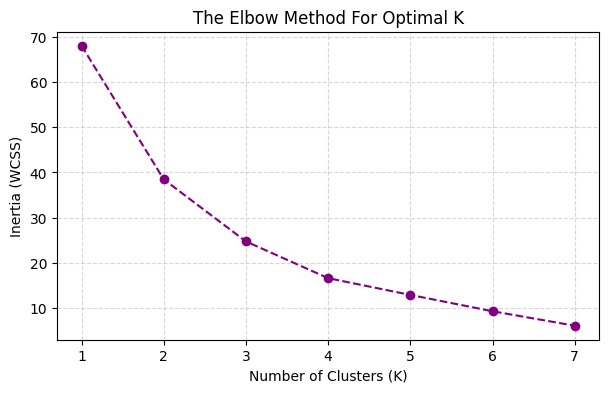

In [74]:
# Plot the Elbow Curve to find the optimal cluster count
plt.figure(figsize=(7, 4))
plt.plot(K_range, inertia, marker="o", linestyle="--", color="purple")
plt.title("The Elbow Method For Optimal K", fontsize=12)
plt.xlabel("Number of Clusters (K)", fontsize=10)
plt.ylabel("Inertia (WCSS)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Apply K-Means with Optimal K

In [75]:
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
subcat_features["Cluster"] = kmeans_final.fit_transform(scaled_features).argmin(
    axis=1
)

### Dimensionality Reduction using PCA for 2D Visual Scatter

In [76]:
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(scaled_features)
subcat_features["PCA1"] = pca_transformed[:, 0]
subcat_features["PCA2"] = pca_transformed[:, 1]

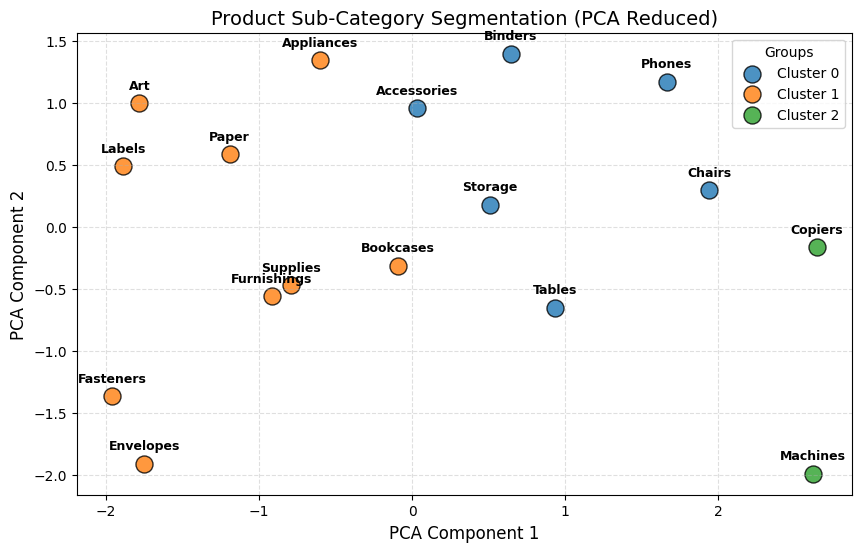

In [77]:
plt.figure(figsize=(10, 6))
colors = ["crimson", "dodgerblue", "forestgreen", "orange"]

for cluster_id in range(optimal_k):
    cluster_data = subcat_features[subcat_features["Cluster"] == cluster_id]
    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        s=150,
        label=f"Cluster {cluster_id}",
        alpha=0.8,
        edgecolors="black",
    )

    # Label data points inline on the scatter canvas
    for idx, row in cluster_data.iterrows():
        plt.annotate(
            idx,
            (row["PCA1"], row["PCA2"]),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=9,
            weight="bold",
        )

plt.title("Product Sub-Category Segmentation (PCA Reduced)", fontsize=14)
plt.xlabel("PCA Component 1", fontsize=12)
plt.ylabel("PCA Component 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Groups")
plt.show()

### Cluster Profile Means

In [79]:
print(subcat_features.groupby("Cluster")[["Total_Sales", "AOV", "Volatility", "YoY_Growth_Rate"]].mean())

           Total_Sales          AOV   Volatility  YoY_Growth_Rate
Cluster                                                          
0        239495.780667   361.131228  3489.056075        24.995322
1         54341.708189   142.746758  1025.825979        19.432222
2        167743.362500  1930.716763  5179.774809         6.841275


### Cluster Group: High Volume, High Volatility (Premium Stars)

High total sales revenue, high Average Order Value (AOV), and high standard deviation (spiky demand patterns). This typically captures sub-categories like Phones and Chairs.

Just-In-Time (JIT) with Buffered Safety Stock. Because these items are high-value revenue drivers but suffer from unpredictable demand surges, keeping massive baseline inventory ties up too much working capital. Instead, establish strong vendor agreements with fast turnaround times and use predictive seasonal forecasts (like our Q4 SARIMA peaks) to stock up right before historically documented peak months.

### Cluster Group: Low Volume, Stable Demand (Core Essentials)

Low to moderate absolute sales revenue, low volatility, low AOV, and stable month-over-month consumption profiles. This includes items like Fasteners, Labels, and Paper.

Continuous Replenishment (Min-Max System). These items are cheap to hold and predictable. Implement an automated reorder point formula: when inventory drops below a fixed threshold, automatically trigger a bulk reorder to restore maximum capacity. This minimizes management overhead while ensuring you never experience a stockout on basic office operational needs.

### Cluster Group: High Volatility, High Ticket Anomaly (Exotic Assets)

Massive AOV spikes combined with hyper-erratic, sparse order volume. This explicitly isolates high-exposure classes like Copiers and Machines.

Make-to-Order / Direct Drop-Shipment. Keeping these highly expensive, slow-moving items sitting on warehouse shelves creates immense inventory holding costs and obsolescence risks. The store should maintain zero baseline stock locally. Instead, route customer orders directly to the manufacturing partner for direct shipping upon transaction clearance.